# 🎧 Audio Classification using Signal Processing + Machine Learning

This project builds an end-to-end audio classification pipeline using signal processing techniques and machine learning models.

The goal is to classify environmental sounds (dog, rain, engine, crying baby) using features extracted from audio signals such as MFCCs, spectral centroid, and zero-crossing rate.

The dataset is 4 classes extracted from the standard esc 50 dataset - totalling 160 samples

## Problem Statement

Given raw audio signals (.wav files), the objective is to extract meaningful features and train a model that can classify sounds into different categories.

Challenges:
- Audio signals are high-dimensional and noisy
- Need to convert time-domain signals into meaningful representations
- Limited dataset size

## 🔬 Feature Extraction

Raw audio signals are not directly suitable for machine learning. Therefore, we extract meaningful features:

### 1. MFCC (Mel-Frequency Cepstral Coefficients)
- Capture the overall spectral shape of audio
- Represent how energy is distributed across frequencies

### 2. MFCC Statistics
- Mean → average spectral behavior
- Standard deviation → variation over time

### 3. Spectral Centroid
- Indicates where the “center of mass” of frequencies lies
- Helps distinguish sharp vs deep sounds

### 4. Zero Crossing Rate (ZCR)
- Measures signal noisiness
- Higher for noisy signals, lower for smooth signals

Final feature vector size: 28 features per audio sample

## 🤖 Model Training

I experimented with multiple models:

- Random Forest Classifier
- Neural Network (MLP)

Cross-validation (5-fold) was used due to limited dataset size to obtain reliable performance estimates.

## 📈 Results

| Model | Accuracy |
|------|--------|
| Random Forest | ~83.7% |
| Neural Network | ~77.5% |

Cross-validation was used to ensure stable evaluation.

## 💡 Key Insights

- Feature engineering significantly improved performance
- MFCC alone was insufficient; adding spectral features improved accuracy
- Random Forest outperformed Neural Networks due to:
  - small dataset size
  - structured tabular features
- Cross-validation provided more reliable results than a single train-test split

## 🚀 Future Work
- Use larger datasets for improved generalization
- Explore deep learning on raw spectrograms
- Perform data augmentation (adding noise, pitch shifts)
- Build real-time audio classification system

In [5]:
import pandas as pd

meta = pd.read_csv("esc50.csv")
print(meta.head())

selected_classes = ["dog", "rain", "engine", "crying_baby"]
meta = meta[meta["category"].isin(selected_classes)]

import os
import librosa
import numpy as np

features = []
labels = []

# building dataset of features and labels
for _, row in meta.iterrows():
    file_path = os.path.join("audio", row["filename"])
    
    y, sr = librosa.load(file_path, sr=22050)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    feature_vector = np.concatenate([mfcc_mean, mfcc_std])
    
    features.append(feature_vector)
    labels.append(row["category"])

# converting to numpy arrays
X = np.array(features)
y = np.array(labels)

print(X.shape, y.shape)

# Checking class distribution
print("Unique labels:", set(y))
print("Samples per class:")
import collections
print(collections.Counter(y))

# Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

# cross-validation with Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(model, X, y_encoded, cv=5)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A
(160, 26) (160,)
Unique labels: {np.str_('crying_baby'), np.str_('rain'), np.str_('dog'), np.str_('engine')}
Samples per class:
Counter({np.str_('dog'): 40, np.str_('rain'): 40, np.str_('engine'): 40, np.str_('crying_baby'): 40})
['crying_baby' 'dog' 'engine' 'rain']
CV scores: [0.875   0.8125  0.75    0.84375 0.8125 ]
Mean accuracy: 0.81875


            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A
(160, 26) (160,)
Unique labels: {np.str_('crying_baby'), np.str_('rain'), np.str_('dog'), np.str_('engine')}
Samples per class:
Counter({np.str_('dog'): 40, np.str_('rain'): 40, np.str_('engine'): 40, np.str_('crying_baby'): 40})
['crying_baby' 'dog' 'engine' 'rain']
CV scores: [0.875   0.8125  0.75    0.84375 0.8125 ]
Mean accuracy: 0.81875


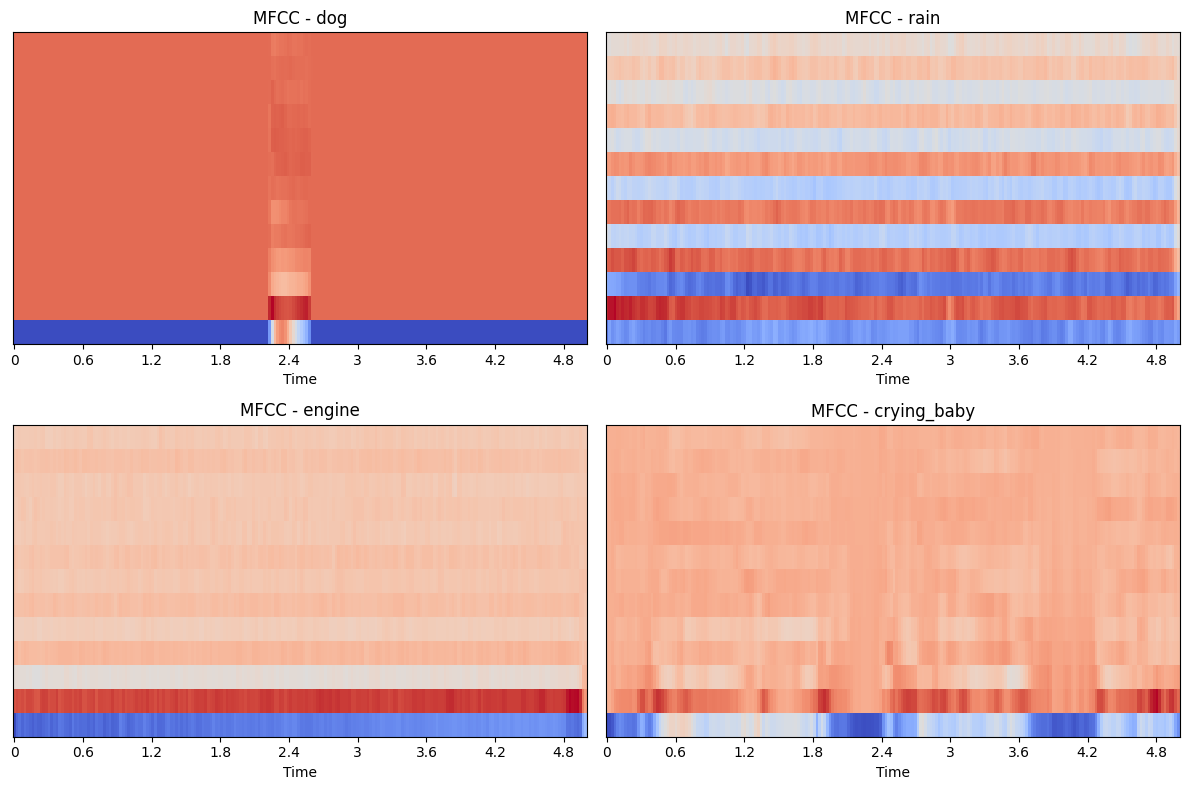

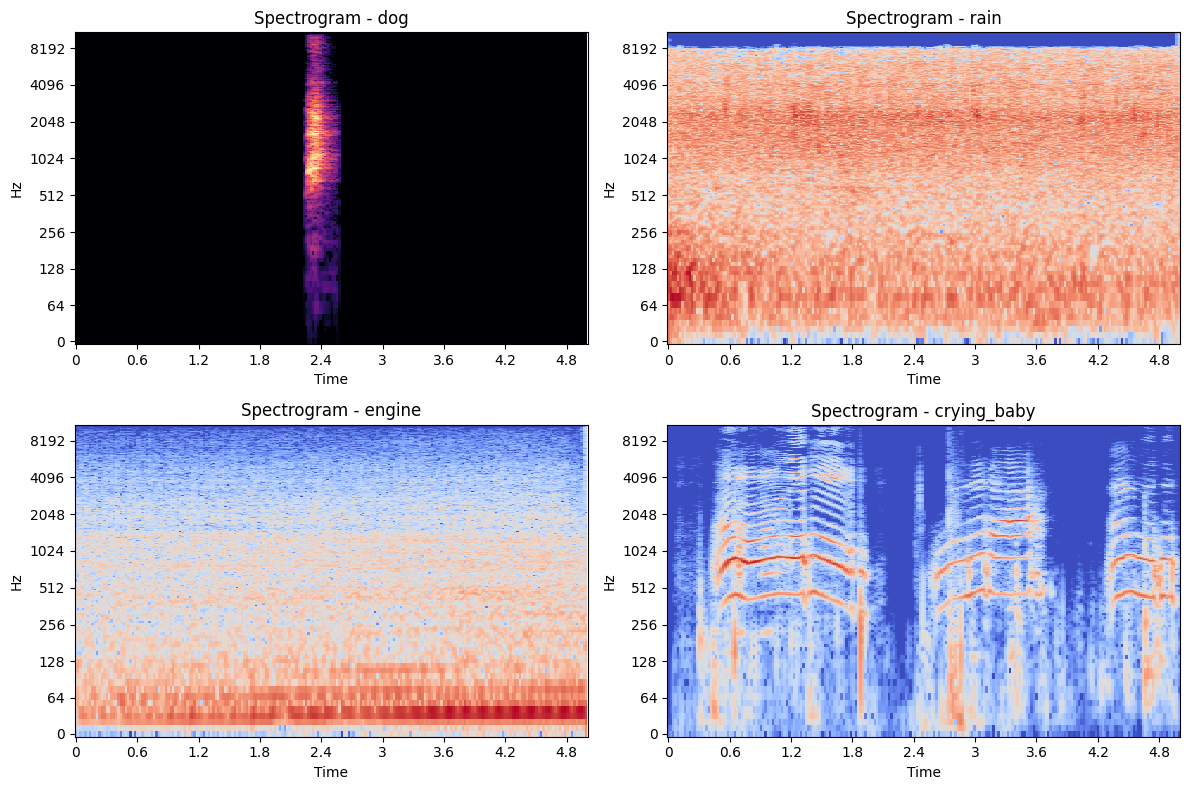

In [10]:
# random forest with feature importance
import pandas as pd

meta = pd.read_csv("esc50.csv")
print(meta.head())

selected_classes = ["dog", "rain", "engine", "crying_baby"]
meta = meta[meta["category"].isin(selected_classes)]

import os
import librosa
import numpy as np

features = []
labels = []

# building dataset of features and labels
for _, row in meta.iterrows():
    file_path = os.path.join("audio", row["filename"])
    
    y, sr = librosa.load(file_path, sr=22050)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    feature_vector = np.concatenate([mfcc_mean, mfcc_std])
    
    features.append(feature_vector)
    labels.append(row["category"])

# converting to numpy arrays
X = np.array(features)
y = np.array(labels)

print(X.shape, y.shape)

# Checking class distribution
print("Unique labels:", set(y))
print("Samples per class:")
import collections
print(collections.Counter(y))

# Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

# cross-validation with Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=42)

scores = cross_val_score(model, X, y_encoded, cv=5)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

# observing difference in plots of audio files across classes
import matplotlib.pyplot as plt
import librosa.display
import os

classes = ["dog", "rain", "engine", "crying_baby"]

sample_files = {}

for c in classes:
    row = meta[meta["category"] == c].iloc[0]
    sample_files[c] = os.path.join("audio", row["filename"])

plt.figure(figsize=(12, 8))

for i, c in enumerate(classes):
    y_audio, sr = librosa.load(sample_files[c], sr=22050)
    mfcc = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=13)
    
    plt.subplot(2, 2, i+1)
    librosa.display.specshow(mfcc, sr=sr, x_axis='time')
    plt.title(f"MFCC - {c}")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))

for i, c in enumerate(classes):
    y_audio, sr = librosa.load(sample_files[c], sr=22050)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y_audio)))
    
    plt.subplot(2, 2, i+1)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
    plt.title(f"Spectrogram - {c}")

plt.tight_layout()
plt.show()

In [7]:
# neural networks
import pandas as pd

meta = pd.read_csv("esc50.csv")
print(meta.head())

selected_classes = ["dog", "rain", "engine", "crying_baby"]
meta = meta[meta["category"].isin(selected_classes)]

import os
import librosa
import numpy as np

features = []
labels = []

# building dataset of features and labels
for _, row in meta.iterrows():
    file_path = os.path.join("audio", row["filename"])
    
    y, sr = librosa.load(file_path, sr=22050)
    
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    feature_vector = np.concatenate([mfcc_mean, mfcc_std])
    
    features.append(feature_vector)
    labels.append(row["category"])

# converting to numpy arrays
X = np.array(features)
y = np.array(labels)

print(X.shape, y.shape)

# Checking class distribution
print("Unique labels:", set(y))
print("Samples per class:")
import collections
print(collections.Counter(y))

# Label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

# scaling features 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# neural network with cross-validation
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(32,),  # one hidden layer
    max_iter=1000,
    random_state=42
)
# evaluate with cross-validation
scores = cross_val_score(model, X_scaled, y_encoded, cv=5)

print("CV scores:", scores)
print("Mean accuracy:", scores.mean())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A
(160, 26) (160,)
Unique labels: {np.str_('crying_baby'), np.str_('rain'), np.str_('dog'), np.str_('engine')}
Samples per class:
Counter({np.str_('dog'): 40, np.str_('rain'): 40, np.str_('engine'): 40, np.str_('crying_baby'): 40})
['crying_baby' 'dog' 'engine' 'rain']
CV scores: [0.875   0.8125  0.71875 0.84375 0.625  ]
Mean accuracy: 0.775


### Feature Visualization Insights

To understand the effectiveness of extracted features, MFCC and spectrogram visualizations were compared across different sound classes.

* **Dog sounds** show sharp, short-duration bursts across frequencies.
* **Rain** exhibits continuous, noise-like patterns spread across time and frequency.
* **Engine sounds** display stable frequency bands, indicating steady tonal components.
* **Crying baby** shows repeated temporal structures with varying frequency content.

These distinct patterns confirm that the extracted features capture meaningful differences between classes, enabling effective classification using machine learning models.
